In [34]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI

In [35]:
load_dotenv()

True

In [36]:
# load_dotenv()
# from langchain_groq import ChatGroq
# # Model
# model = ChatGroq(
#     model="openai/gpt-oss-120b",
#     temperature=0.1)

In [37]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

In [38]:
class ChatState(MessagesState):
    summary: str

In [39]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [40]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [41]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [42]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [43]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

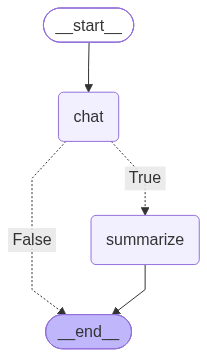

In [44]:
graph

In [45]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [46]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [47]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='dd09c5c2-2a3e-45f9-8dad-749518629cf7')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : [{'type': 'text', 'text': '**Quantum Physics** (or Quantum Mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (like electrons, protons, neutrons, and photons). \n\nWhile classical physics (Isaac Newton’s laws) explains the world we see around us—like how cars move or why apples fall—it completely breaks down at the microscopic level. At the quantum level, the universe operates under a set of rules that seem strange, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, history, and real-world applications of quantum physics.\n\n---\n\n### 1. Key Concepts of Quantum Physics\n\n#### A. Quantization (Where the name comes from)\n

In [48]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='dd09c5c2-2a3e-45f9-8dad-749518629cf7'), AIMessage(content=[{'type': 'text', 'text': '**Quantum Physics** (or Quantum Mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (like electrons, protons, neutrons, and photons). \n\nWhile classical physics (Isaac Newton’s laws) explains the world we see around us—like how cars move or why apples fall—it completely breaks down at the microscopic level. At the quantum level, the universe operates under a set of rules that seem strange, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, history, and real-world applications of quantum physics.\n\n---\n\n### 1. Key Concepts of Quantum Physics\n\n#### A. Quantization (Where the name comes from)\nIn classical physics, energy is continuous (like a ramp). In quantum physics, en

In [49]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='dd09c5c2-2a3e-45f9-8dad-749518629cf7'), AIMessage(content=[{'type': 'text', 'text': '**Quantum Physics** (or Quantum Mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (like electrons, protons, neutrons, and photons). \n\nWhile classical physics (Isaac Newton’s laws) explains the world we see around us—like how cars move or why apples fall—it completely breaks down at the microscopic level. At the quantum level, the universe operates under a set of rules that seem strange, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, history, and real-world applications of quantum physics.\n\n---\n\n### 1. Key Concepts of Quantum Physics\n\n#### A. Quantization (Where the name comes from)\nIn classical physics, energy is continuous (like a ramp). In quantum physics, en

In [50]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='dd09c5c2-2a3e-45f9-8dad-749518629cf7'), AIMessage(content=[{'type': 'text', 'text': '**Quantum Physics** (or Quantum Mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (like electrons, protons, neutrons, and photons). \n\nWhile classical physics (Isaac Newton’s laws) explains the world we see around us—like how cars move or why apples fall—it completely breaks down at the microscopic level. At the quantum level, the universe operates under a set of rules that seem strange, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, history, and real-world applications of quantum physics.\n\n---\n\n### 1. Key Concepts of Quantum Physics\n\n#### A. Quantization (Where the name comes from)\nIn classical physics, energy is continuous (like a ramp). In quantum physics, en